# Logistic Regression — Complete Mathematical & Practical Guide

**Learning sequence:** Problem → Intuition → Mathematics → From Scratch → Visualization → Scikit-learn → Evaluation → Regularization → Multiclass → Failure Cases → Practical Workflow

This notebook is a complete learning resource for Logistic Regression. It connects mathematical foundations, implementation, visualization, model evaluation, regularization, and practical machine-learning workflow.

### Main topics
- Classification vs. regression
- Sigmoid, odds, and log-odds
- Logistic Regression mathematics
- Maximum likelihood and binary cross-entropy
- Gradient descent
- Logistic Regression from scratch
- Decision boundaries and probability surfaces
- Scikit-learn implementation
- Breast Cancer Wisconsin dataset
- Accuracy, Precision, Recall, F1, ROC-AUC
- Confusion matrix
- ROC and Precision-Recall curves
- Threshold tuning
- Underfitting and overfitting
- L1 and L2 regularization
- Feature scaling and data leakage
- Class imbalance
- Multiclass Logistic Regression
- Cross-validation and GridSearchCV
- Coefficient and odds-ratio interpretation
- Common failure modes
- Biomedical and Bioinformatics applications

All code cells contain precise English comments explaining important operations and parameters.

In [1]:
# Import numerical computing and data-analysis libraries.
import numpy as np
import pandas as pd

# Import plotting libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Import mglearn for educational machine-learning datasets.
import mglearn

# Import scikit-learn datasets, preprocessing, models, model selection, and metrics.
from sklearn.datasets import load_breast_cancer, load_iris, make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve,
    roc_auc_score, precision_recall_curve, average_precision_score
)

# Apply a clean scientific visualization theme.
sns.set_theme(style="whitegrid", context="notebook")

# Make NumPy output easier to inspect.
np.set_printoptions(precision=4, suppress=True)

## 1. Classification vs. Regression

Linear Regression predicts a continuous numerical value:

$$
\hat y=b_0+b_1x_1+\cdots+b_dx_d
$$

Classification predicts a discrete class:

$$
y\in\{0,1\}
$$

Logistic Regression estimates:

$$
P(y=1\mid X)
$$

The central idea is:

$$
\boxed{\text{Linear score}\rightarrow\text{Sigmoid}\rightarrow\text{Probability}\rightarrow\text{Class}}
$$

## 2. Why Linear Regression is not a Proper Probabilistic Classifier

A linear model is unbounded:

$$
-\infty < \hat y < +\infty
$$

A probability must satisfy:

$$
0\leq p\leq1
$$

Logistic Regression solves this by transforming the linear score through the sigmoid function:

$$
z=b_0+b_1x_1+\cdots+b_dx_d
$$

$$
p=\sigma(z)
$$

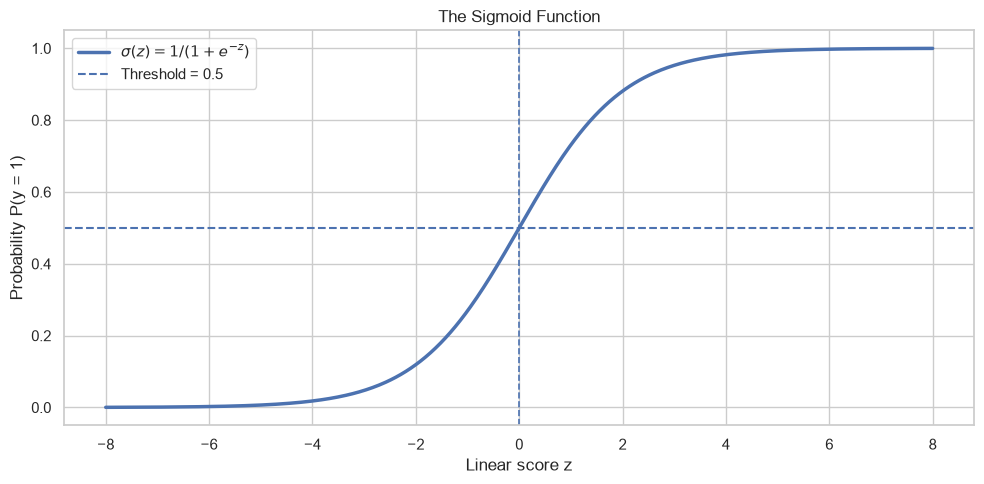

In [2]:
# Create a range of possible linear scores.
z = np.linspace(-8, 8, 500)

# Define the sigmoid function.
# The sigmoid maps any real-valued number into the interval (0, 1).
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Convert linear scores into probabilities.
p = sigmoid(z)

# Create the sigmoid plot.
plt.figure(figsize=(10, 5))
plt.plot(z, p, linewidth=2.5, label=r"$\sigma(z)=1/(1+e^{-z})$")
plt.axhline(0.5, linestyle="--", linewidth=1.5, label="Threshold = 0.5")
plt.axvline(0, linestyle="--", linewidth=1.2)
plt.xlabel("Linear score z")
plt.ylabel("Probability P(y = 1)")
plt.title("The Sigmoid Function")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Odds and Log-Odds

For a probability $p$, define the odds:

$$
\text{odds}=\frac{p}{1-p}
$$

The log-odds, or logit, is:

$$
\log\left(\frac{p}{1-p}\right)
$$

Logistic Regression assumes:

$$
\log\left(\frac{p}{1-p}\right)
=
b_0+b_1x_1+\cdots+b_dx_d
$$

Solving for $p$ gives:

$$
p=
\frac{1}{1+e^{-(b_0+b_1x_1+\cdots+b_dx_d)}}
$$

For coefficient $b_j$, the corresponding odds ratio is:

$$
OR_j=e^{b_j}
$$

## 4. Maximum Likelihood and Binary Cross-Entropy

For observation $i$:

$$
P(y_i\mid X_i)=p_i^{y_i}(1-p_i)^{1-y_i}
$$

For all observations:

$$
L(\beta)=\prod_{i=1}^{n}p_i^{y_i}(1-p_i)^{1-y_i}
$$

We minimize negative log-likelihood:

$$
J(\beta)=
-\frac1n\sum_{i=1}^{n}
\left[
y_i\log(p_i)+(1-y_i)\log(1-p_i)
\right]
$$

This is binary cross-entropy, commonly called **log loss**.

In [3]:
# Define binary cross-entropy manually.
def binary_cross_entropy(y_true, y_prob):
    # Prevent log(0), which would create numerical instability.
    epsilon = 1e-15
    y_prob = np.clip(y_prob, epsilon, 1 - epsilon)

    # Calculate the mean negative log-likelihood.
    return -np.mean(
        y_true * np.log(y_prob)
        + (1 - y_true) * np.log(1 - y_prob)
    )

# Create a small example of true labels.
y_example = np.array([1, 1, 0, 0])

# Create predicted probabilities.
p_example = np.array([0.90, 0.60, 0.20, 0.05])

# Calculate and display the loss.
print("Binary cross-entropy:", binary_cross_entropy(y_example, p_example))

Binary cross-entropy: 0.22265574628139434


## 5. Gradient Descent

Let:

$$
z=X\beta
$$

and:

$$
p=\sigma(z)
$$

For average binary cross-entropy:

$$
\nabla J(\beta)=\frac1nX^T(p-y)
$$

Gradient descent updates:

$$
\beta\leftarrow\beta-\alpha\nabla J(\beta)
$$

where $\alpha$ is the learning rate.

The training loop is:

$$
\text{Predict}\rightarrow\text{Loss}\rightarrow\text{Gradient}\rightarrow\text{Update}
$$

In [4]:
# Create a two-dimensional binary classification dataset.
X_s, y_s = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

# Standardize the features before gradient descent.
scaler_s = StandardScaler()
X_s = scaler_s.fit_transform(X_s)

# Add a column of ones to represent the intercept.
X_design = np.c_[np.ones(X_s.shape[0]), X_s]

# Implement Logistic Regression with batch gradient descent.
def logistic_regression_from_scratch(X, y, learning_rate=0.1, n_iterations=2000):
    # Initialize all coefficients to zero.
    weights = np.zeros(X.shape[1])

    # Store loss values so convergence can be visualized.
    losses = []

    for _ in range(n_iterations):
        # Calculate the linear score.
        z = X @ weights

        # Convert the score into probabilities.
        probabilities = sigmoid(z)

        # Calculate the gradient of binary cross-entropy.
        gradient = (X.T @ (probabilities - y)) / len(y)

        # Update the coefficients.
        weights -= learning_rate * gradient

        # Store the current loss.
        losses.append(binary_cross_entropy(y, probabilities))

    return weights, losses

# Train the model from scratch.
weights, losses = logistic_regression_from_scratch(
    X_design,
    y_s,
    learning_rate=0.1,
    n_iterations=2000
)

# Display the learned parameters.
print("Learned parameters:", weights)

Learned parameters: [0.1588 0.4944 5.869 ]


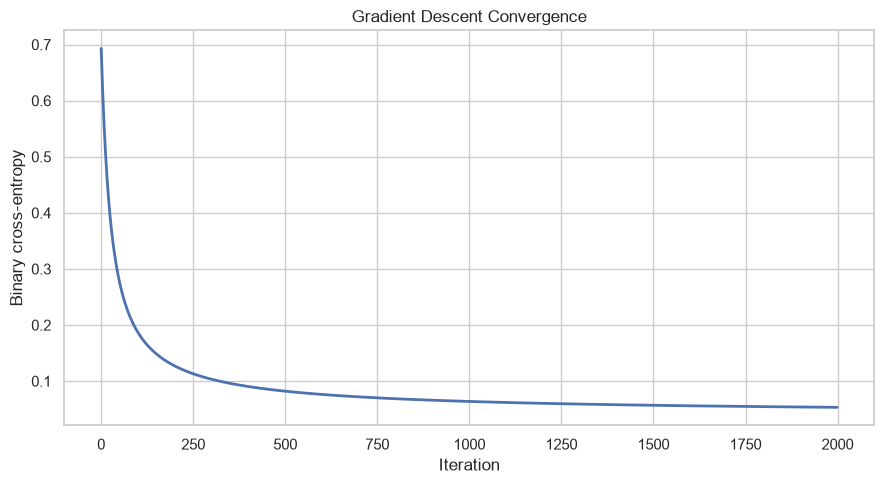

In [5]:
# Plot the optimization history.
plt.figure(figsize=(9, 5))
plt.plot(losses, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Binary cross-entropy")
plt.title("Gradient Descent Convergence")
plt.tight_layout()
plt.show()

## 6. Decision Boundary

For the standard threshold:

$$
p=0.5
$$

the sigmoid input must satisfy:

$$
z=0
$$

For two features:

$$
b_0+b_1x_1+b_2x_2=0
$$

Therefore:

$$
x_2=-\frac{b_0+b_1x_1}{b_2}
$$

Ordinary Logistic Regression creates a **linear decision boundary** in feature space.

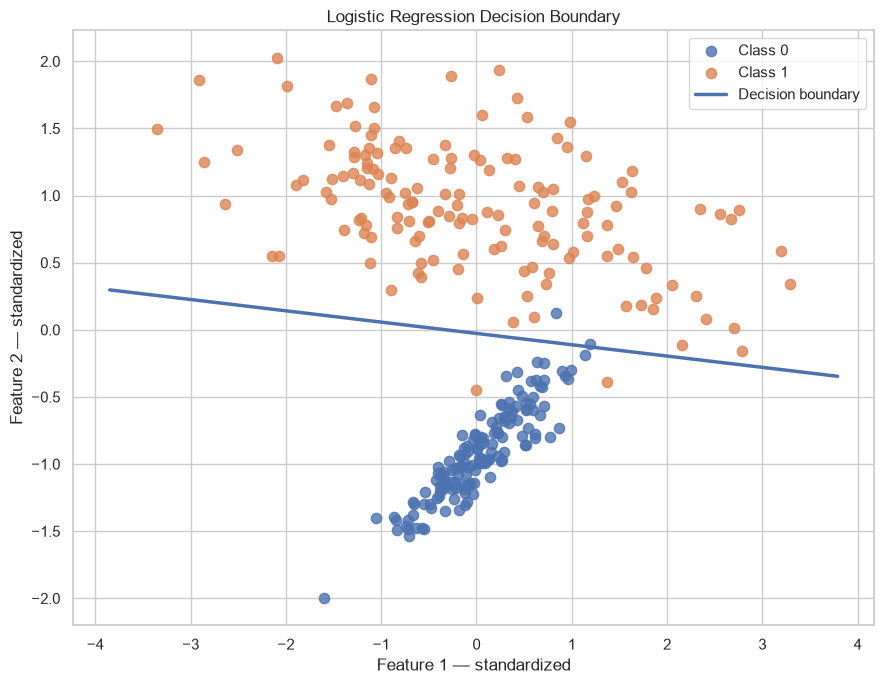

In [6]:
# Extract the intercept and two feature coefficients.
b0, b1, b2 = weights

# Create x-values for the boundary.
x1 = np.linspace(
    X_s[:, 0].min() - 0.5,
    X_s[:, 0].max() + 0.5,
    300
)

# Solve the boundary equation for x2.
x2 = -(b0 + b1 * x1) / b2

# Create the decision-boundary visualization.
plt.figure(figsize=(9, 7))

# Plot class 0 observations.
plt.scatter(
    X_s[y_s == 0, 0],
    X_s[y_s == 0, 1],
    s=55,
    alpha=0.8,
    label="Class 0"
)

# Plot class 1 observations.
plt.scatter(
    X_s[y_s == 1, 0],
    X_s[y_s == 1, 1],
    s=55,
    alpha=0.8,
    label="Class 1"
)

# Plot the learned boundary.
plt.plot(
    x1,
    x2,
    linewidth=2.5,
    label="Decision boundary"
)

plt.xlabel("Feature 1 — standardized")
plt.ylabel("Feature 2 — standardized")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Probability Surface

A Logistic Regression model estimates:

$$
P(y=1\mid X)
$$

For two features, we can visualize this probability across a dense feature-space grid.

The contour:

$$
P(y=1\mid X)=0.5
$$

is the standard decision boundary.

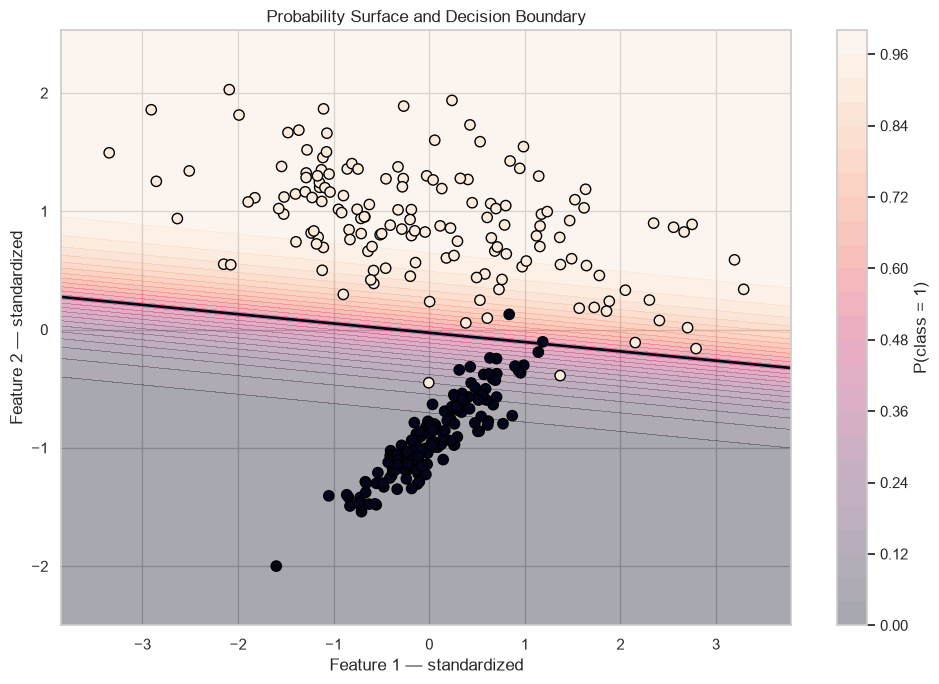

In [7]:
# Train scikit-learn Logistic Regression on the two-dimensional dataset.
demo_model = LogisticRegression(
    C=1.0,
    max_iter=2000,
    random_state=42
)

demo_model.fit(X_s, y_s)

# Create a dense grid over the feature space.
xx, yy = np.meshgrid(
    np.linspace(X_s[:, 0].min() - 0.5, X_s[:, 0].max() + 0.5, 300),
    np.linspace(X_s[:, 1].min() - 0.5, X_s[:, 1].max() + 0.5, 300)
)

# Convert the grid into rows for prediction.
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict class-1 probabilities for every grid point.
probability = demo_model.predict_proba(grid)[:, 1].reshape(xx.shape)

# Draw the probability surface.
plt.figure(figsize=(10, 7))
contour = plt.contourf(xx, yy, probability, levels=25, alpha=0.35)

# Draw the 0.5 probability contour.
plt.contour(xx, yy, probability, levels=[0.5], linewidths=2)

# Overlay the observations.
plt.scatter(
    X_s[:, 0],
    X_s[:, 1],
    c=y_s,
    s=55,
    edgecolor="black"
)

# Add a probability color scale.
plt.colorbar(contour, label="P(class = 1)")
plt.xlabel("Feature 1 — standardized")
plt.ylabel("Feature 2 — standardized")
plt.title("Probability Surface and Decision Boundary")
plt.tight_layout()
plt.show()

## 8. `mglearn` Visualization

`mglearn` is useful for educational datasets and visual explanations.

Because plotting helpers can differ between installed versions, this notebook uses a stable mglearn dataset and constructs the probability visualization explicitly with Matplotlib.

This makes the model behavior transparent and avoids relying on version-specific helper functions.

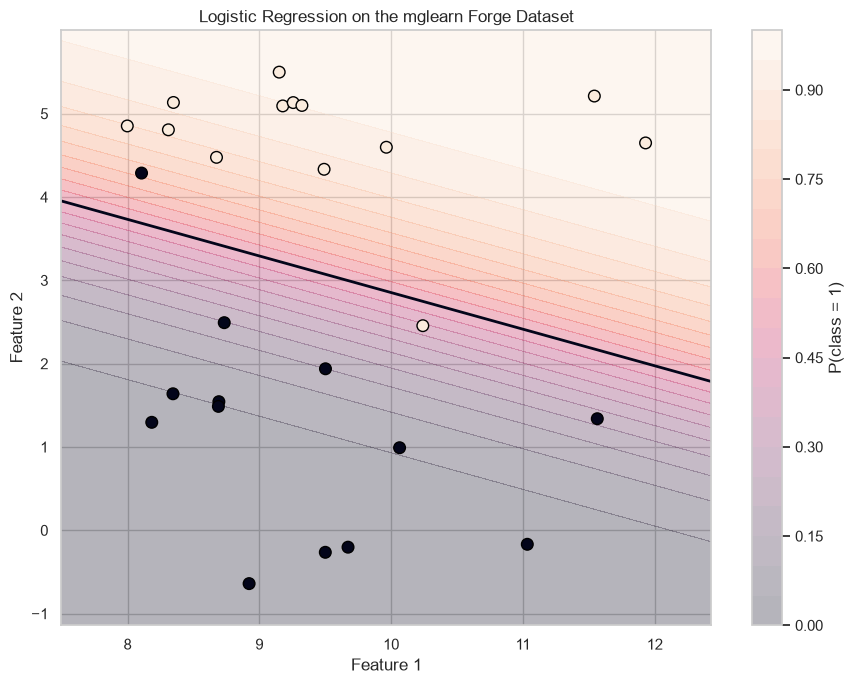

In [10]:
# Generate the built-in two-dimensional classification dataset from mglearn.
# The Forge dataset has a fixed dataset size and does not accept parameters
# such as n_samples or random_state in this mglearn version.
X_mg, y_mg = mglearn.datasets.make_forge()

# Fit Logistic Regression to the mglearn dataset.
mg_model = LogisticRegression(
    C=1.0,
    max_iter=2000,
    random_state=42
)

mg_model.fit(
    X_mg,
    y_mg
)

# Create a dense feature-space grid.
gx, gy = np.meshgrid(
    np.linspace(
        X_mg[:, 0].min() - 0.5,
        X_mg[:, 0].max() + 0.5,
        300
    ),
    np.linspace(
        X_mg[:, 1].min() - 0.5,
        X_mg[:, 1].max() + 0.5,
        300
    )
)

# Predict class-1 probabilities across the grid.
gp = mg_model.predict_proba(
    np.c_[gx.ravel(), gy.ravel()]
)[:, 1].reshape(gx.shape)

# Visualize the probability surface and decision boundary.
plt.figure(figsize=(9, 7))

filled = plt.contourf(
    gx,
    gy,
    gp,
    levels=20,
    alpha=0.30
)

# The 0.5 probability contour represents the decision boundary.
plt.contour(
    gx,
    gy,
    gp,
    levels=[0.5],
    linewidths=2
)

# Plot the original observations.
plt.scatter(
    X_mg[:, 0],
    X_mg[:, 1],
    c=y_mg,
    s=70,
    edgecolor="black"
)

# Display the probability scale.
plt.colorbar(
    filled,
    label="P(class = 1)"
)

# Add labels and title.
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression on the mglearn Forge Dataset")

plt.tight_layout()
plt.show()

## 9. Real Dataset — Breast Cancer Wisconsin

We now use the built-in scikit-learn dataset:

`load_breast_cancer()`

It contains numerical measurements derived from breast mass images and a binary target.

This is excellent for learning classification workflows.

**Important:** performance on this educational dataset must not be interpreted as clinical validation.

In [11]:
# Load the built-in Breast Cancer Wisconsin dataset.
cancer = load_breast_cancer()

# Convert the feature matrix into a labeled DataFrame.
X_cancer = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

# Store the target vector as a Series.
y_cancer = pd.Series(
    cancer.target,
    name="target"
)

# Inspect dataset dimensions and class names.
print("Feature matrix shape:", X_cancer.shape)
print("Target shape:", y_cancer.shape)
print("Classes:", cancer.target_names)

# Display the first five observations.
display(X_cancer.head())

Feature matrix shape: (569, 30)
Target shape: (569,)
Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


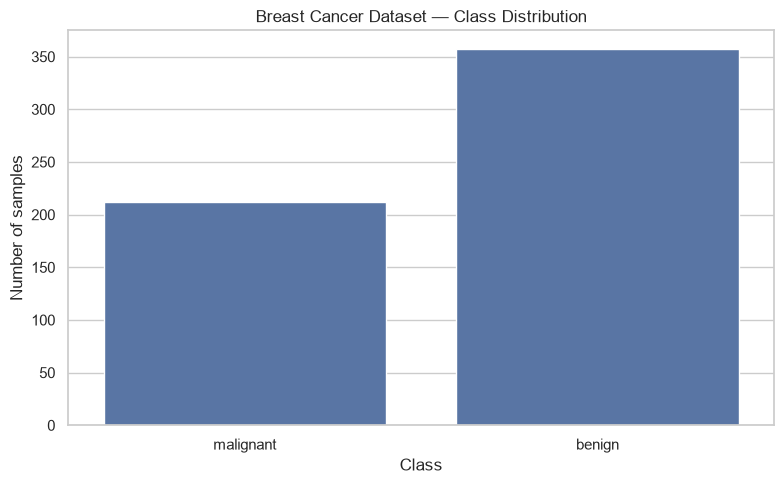

In [12]:
# Display descriptive statistics.
display(X_cancer.describe().T)

# Convert numeric target labels into readable class names.
class_labels = y_cancer.map({
    0: cancer.target_names[0],
    1: cancer.target_names[1]
})

# Plot the class distribution.
plt.figure(figsize=(8, 5))
sns.countplot(x=class_labels)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Breast Cancer Dataset — Class Distribution")
plt.tight_layout()
plt.show()

## 10. Train/Test Split and Data Leakage

The safe workflow is:

$$
\text{Split}
\rightarrow
\text{Fit preprocessing on training data}
\rightarrow
\text{Transform}
\rightarrow
\text{Fit model}
$$

Do not fit a scaler on the entire dataset before splitting.

A `Pipeline` is particularly important during cross-validation because each fold must learn preprocessing only from its training portion.

In [16]:
# Split the dataset while preserving class proportions.
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.20,
    stratify=y_cancer,
    random_state=42
)

# Build a leakage-safe pipeline.
cancer_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logistic_regression",
        LogisticRegression(
            C=1.0,
            solver="lbfgs",
            max_iter=5000,
            random_state=42
        )
    )
])

# Fit preprocessing and the model using training data only.
cancer_model.fit(
    X_train,
    y_train
)

# Generate hard predictions.
y_pred = cancer_model.predict(X_test)

# Generate positive-class probabilities.
y_prob = cancer_model.predict_proba(X_test)[:, 1]

# Display several predicted probabilities.
print("First five probabilities:", y_prob[:5])

First five probabilities: [0.     1.     0.0064 0.5335 0.    ]


## 11. Classification Metrics

Accuracy:

$$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$$

Precision:

$$
Precision=\frac{TP}{TP+FP}
$$

Recall:

$$
Recall=\frac{TP}{TP+FN}
$$

F1:

$$
F_1=2\frac{Precision\cdot Recall}{Precision+Recall}
$$

ROC-AUC evaluates ranking/discrimination across thresholds.

No single metric is universally sufficient. Metric selection should follow the scientific question and the consequences of errors.

In [17]:
# Calculate standard classification metrics.
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

# Print each metric with four decimal places.
for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

# Display the complete class-level report.
print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=cancer.target_names
    )
)

Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1        : 0.9861
ROC-AUC   : 0.9954

Classification report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



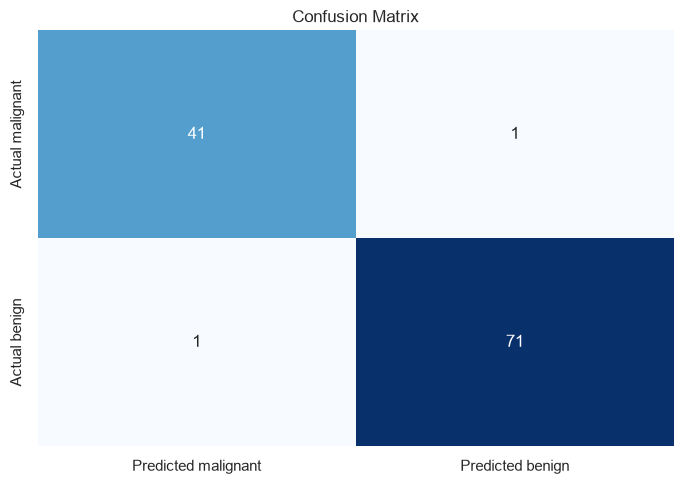

In [18]:
# Calculate the confusion matrix.
cm = confusion_matrix(y_test, y_pred)

# Add readable row and column labels.
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {name}" for name in cancer.target_names],
    columns=[f"Predicted {name}" for name in cancer.target_names]
)

# Visualize the confusion matrix.
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. Threshold Tuning

The default classification rule is usually:

$$
p\geq0.5\Rightarrow\hat y=1
$$

But the threshold can be changed.

Lower thresholds generally produce more positive predictions.

Higher thresholds generally produce fewer positive predictions.

The threshold should be selected using validation data or a predefined decision policy, not repeatedly optimized on the final test set.

In [19]:
# Define candidate probability thresholds.
thresholds = [0.20, 0.35, 0.50, 0.65, 0.80]

# Store threshold-specific metrics.
threshold_results = []

for threshold in thresholds:
    # Convert probabilities into binary predictions.
    pred = (y_prob >= threshold).astype(int)

    # Store the relevant metrics.
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0)
    })

# Convert the results into a DataFrame.
threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,threshold,precision,recall,f1
0,0.20,0.972973,1.000000,0.986301
1,0.35,0.972973,1.000000,0.986301
2,0.50,0.986111,0.986111,0.986111
3,0.65,0.985294,0.930556,0.957143
4,0.80,0.985075,0.916667,0.949640


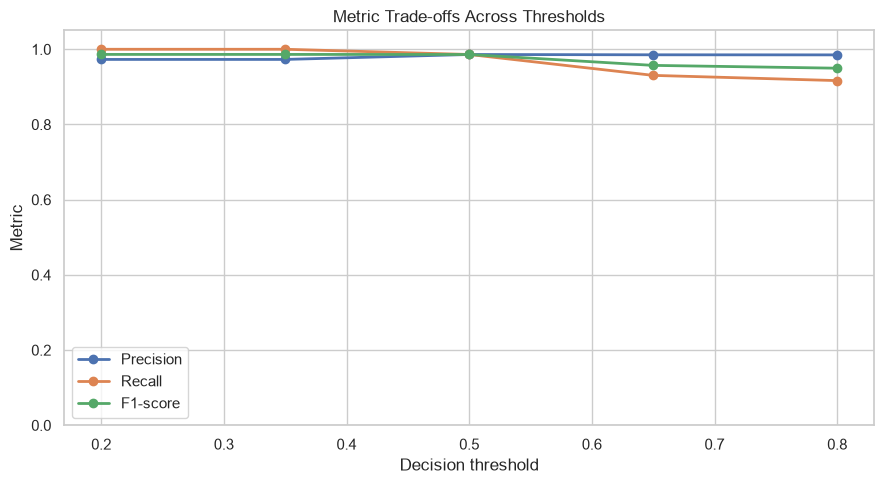

In [20]:
# Plot how the threshold changes precision, recall, and F1.
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    linewidth=2,
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    linewidth=2,
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    linewidth=2,
    label="F1-score"
)

plt.xlabel("Decision threshold")
plt.ylabel("Metric")
plt.title("Metric Trade-offs Across Thresholds")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## 13. ROC Curve

The ROC curve uses:

$$
TPR=\frac{TP}{TP+FN}
$$

and:

$$
FPR=\frac{FP}{FP+TN}
$$

ROC-AUC summarizes ranking performance over classification thresholds.

An AUC of 0.5 corresponds to random ranking in the idealized interpretation, while 1.0 represents perfect ranking on the evaluated sample.

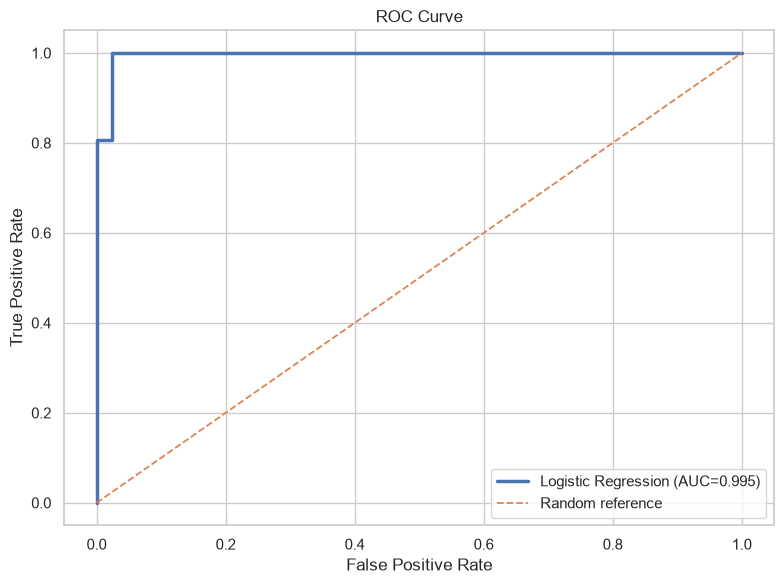

In [21]:
# Calculate false-positive and true-positive rates.
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_prob
)

# Calculate ROC-AUC.
auc_value = roc_auc_score(
    y_test,
    y_prob
)

# Plot the ROC curve.
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"Logistic Regression (AUC={auc_value:.3f})"
)

# Add the random-classifier reference.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.3,
    label="Random reference"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Precision-Recall Curve

The Precision-Recall curve shows the relationship between:

$$
Precision=\frac{TP}{TP+FP}
$$

and:

$$
Recall=\frac{TP}{TP+FN}
$$

This view can be especially useful when the positive class is uncommon.

Average Precision summarizes precision-recall ranking behavior.

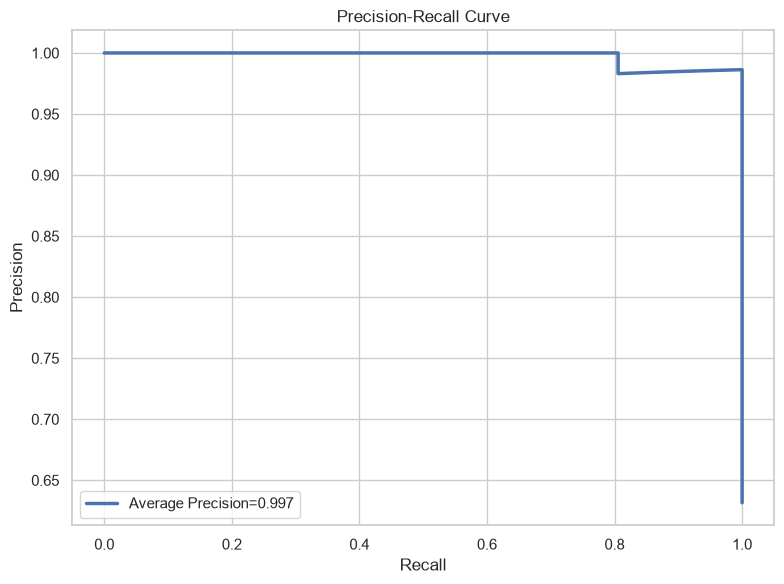

In [22]:
# Calculate precision and recall across thresholds.
precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob
)

# Calculate Average Precision.
ap = average_precision_score(
    y_test,
    y_prob
)

# Plot the Precision-Recall curve.
plt.figure(figsize=(8, 6))
plt.plot(
    recall_values,
    precision_values,
    linewidth=2.5,
    label=f"Average Precision={ap:.3f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 15. Underfitting, Overfitting, and Regularization

For scikit-learn Logistic Regression, `C` is the **inverse** of regularization strength:

$$
C\downarrow\Rightarrow\text{stronger regularization}
$$

$$
C\uparrow\Rightarrow\text{weaker regularization}
$$

Strong regularization can produce underfitting.

Very weak regularization can allow the model to fit noise more strongly.

We examine training and cross-validation behavior rather than selecting a model by repeatedly looking at the final test set.

In [24]:
# Define a logarithmic range of regularization strengths.
C_values = np.logspace(-4, 4, 17)

# Create reproducible stratified cross-validation folds.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Store results for each regularization strength.
regularization_results = []

for C_value in C_values:
    # Build a fresh leakage-safe pipeline.
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "logistic_regression",
            LogisticRegression(
                C=C_value,
                solver="lbfgs",
                max_iter=5000,
                random_state=42
            )
        )
    ])

    # Calculate cross-validation accuracy.
    cv_scores = cross_val_score(
        model,
        X_cancer,
        y_cancer,
        cv=cv,
        scoring="accuracy"
    )

    # Fit the model on the training split.
    model.fit(X_train, y_train)

    # Store training and cross-validation performance.
    regularization_results.append({
        "C": C_value,
        "train_accuracy": model.score(X_train, y_train),
        "cv_accuracy": cv_scores.mean()
    })

# Convert the results to a DataFrame.
regularization_df = pd.DataFrame(regularization_results)

display(regularization_df)

,C,train_accuracy,cv_accuracy
0,0.000100,0.639560,0.643270
1,0.000316,0.806593,0.794457
2,0.001000,0.887912,0.894566
3,0.003162,0.942857,0.934995
4,0.010000,0.956044,0.949045
5,0.031623,0.978022,0.966620
6,0.100000,0.986813,0.973669
7,0.316228,0.989011,0.973669
8,1.000000,0.989011,0.973669
9,3.162278,0.989011,0.971914


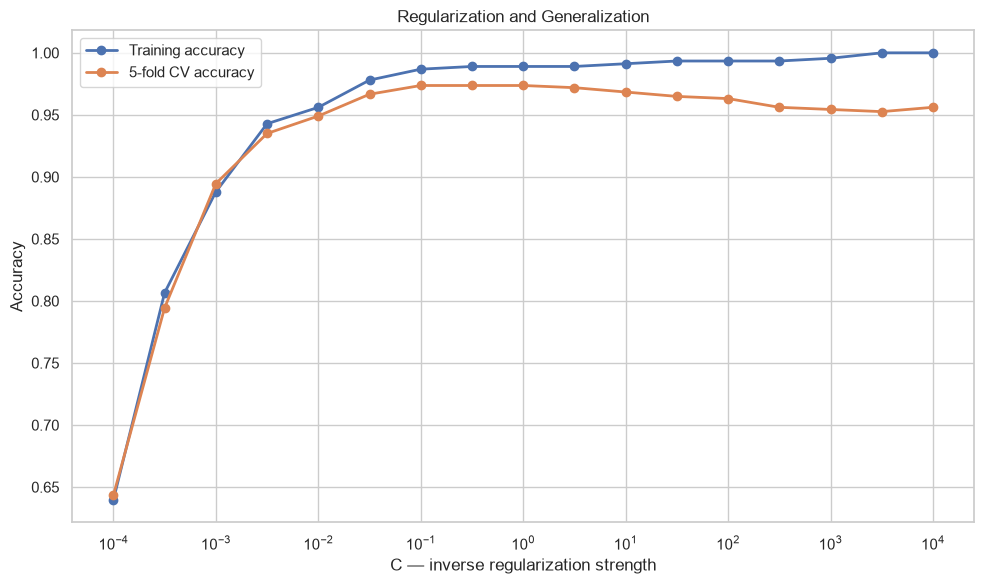

In [25]:
# Plot training and cross-validation performance.
plt.figure(figsize=(10, 6))

plt.semilogx(
    regularization_df["C"],
    regularization_df["train_accuracy"],
    marker="o",
    linewidth=2,
    label="Training accuracy"
)

plt.semilogx(
    regularization_df["C"],
    regularization_df["cv_accuracy"],
    marker="o",
    linewidth=2,
    label="5-fold CV accuracy"
)

plt.xlabel("C — inverse regularization strength")
plt.ylabel("Accuracy")
plt.title("Regularization and Generalization")
plt.legend()
plt.tight_layout()
plt.show()

## 16. L1 vs. L2 Regularization

L2:

$$
J_{L2}=J+\lambda\sum_j\beta_j^2
$$

L1:

$$
J_{L1}=J+\lambda\sum_j|\beta_j|
$$

L2 usually shrinks coefficients toward zero.

L1 can make some coefficients exactly zero, producing a sparse model.

In high-dimensional scientific data, L1 can therefore act as embedded feature selection. However, a selected feature is not automatically a biological or causal biomarker.

In [27]:
# Build an L1-regularized Logistic Regression pipeline.
l1_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic_regression",
        LogisticRegression(
            C=0.1,
            solver="liblinear",
            max_iter=5000,
            random_state=42
        )
    )
])

# Fit the sparse model.
l1_model.fit(X_train, y_train)

# Extract the learned coefficient vector.
l1_coefficients = (
    l1_model
    .named_steps["logistic_regression"]
    .coef_[0]
)

# Count approximately zero coefficients.
zero_count = np.isclose(
    l1_coefficients,
    0
).sum()

print(
    "Approximately zero coefficients:",
    zero_count,
    "of",
    len(l1_coefficients)
)

Approximately zero coefficients: 0 of 30


## 17. Feature Correlation and Multicollinearity

Strongly correlated predictors can make individual coefficients unstable.

A correlation matrix is useful for exploratory analysis, although correlation alone does not prove problematic multicollinearity.

This issue is especially relevant in biomedical data because multiple measurements can represent related biological or imaging properties.

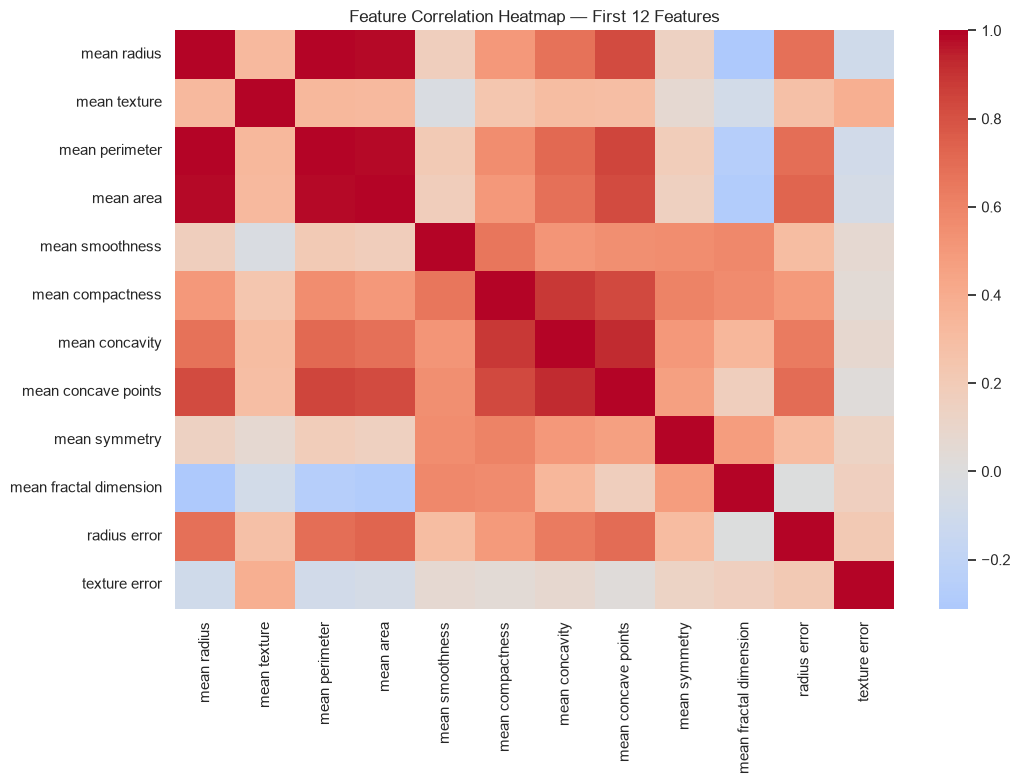

In [28]:
# Calculate pairwise feature correlations.
correlation_matrix = X_cancer.corr()

# Plot a manageable subset of the correlation matrix.
plt.figure(figsize=(11, 8))
sns.heatmap(
    X_cancer.iloc[:, :12].corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlation Heatmap — First 12 Features")
plt.tight_layout()
plt.show()

## 18. Class Imbalance

Accuracy can be misleading when one class dominates.

For example, if 90% of observations belong to class 0, predicting class 0 for every sample achieves 90% accuracy but has zero recall for class 1.

Scikit-learn supports:

```python
class_weight="balanced"
```

This changes the effective weighting of classes during optimization.

It is not a universal fix: threshold choice, sampling design, evaluation metrics, and the scientific cost of errors still matter.

In [29]:
# Generate an intentionally imbalanced classification problem.
X_imb, y_imb = make_classification(
    n_samples=1200,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    weights=[0.90, 0.10],
    random_state=42
)

# Split the data while preserving the minority-class proportion.
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_imb,
    y_imb,
    test_size=0.20,
    stratify=y_imb,
    random_state=42
)

# Create the standard Logistic Regression pipeline.
standard_imb = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logreg",
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    )
])

# Create a class-weighted Logistic Regression pipeline.
balanced_imb = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logreg",
        LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        )
    )
])

# Fit both models.
standard_imb.fit(Xi_train, yi_train)
balanced_imb.fit(Xi_train, yi_train)

# Generate predictions.
pred_standard = standard_imb.predict(Xi_test)
pred_balanced = balanced_imb.predict(Xi_test)

# Compare minority-class metrics.
comparison = pd.DataFrame({
    "model": ["Standard", "Balanced"],
    "precision": [
        precision_score(yi_test, pred_standard),
        precision_score(yi_test, pred_balanced)
    ],
    "recall": [
        recall_score(yi_test, pred_standard),
        recall_score(yi_test, pred_balanced)
    ],
    "f1": [
        f1_score(yi_test, pred_standard),
        f1_score(yi_test, pred_balanced)
    ]
})

display(comparison)

,model,precision,recall,f1
0,Standard,0.666667,0.24,0.352941
1,Balanced,0.218750,0.56,0.314607


## 19. Multiclass Logistic Regression

For $K$ classes, multinomial Logistic Regression uses the softmax function:

$$
P(y=k\mid X)=
\frac{e^{z_k}}
{\sum_{j=1}^{K}e^{z_j}}
$$

The probabilities satisfy:

$$
\sum_{k=1}^{K}P(y=k\mid X)=1
$$

We demonstrate multiclass Logistic Regression using the built-in Iris dataset.

In [30]:
# Load the built-in Iris dataset.
iris = load_iris()

# Split the data while preserving class proportions.
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.20,
    stratify=iris.target,
    random_state=42
)

# Build a scaled multiclass Logistic Regression pipeline.
iris_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logreg",
        LogisticRegression(
            C=1.0,
            max_iter=5000,
            random_state=42
        )
    )
])

# Fit the model.
iris_model.fit(Xi_train, yi_train)

# Predict class labels.
iris_pred = iris_model.predict(Xi_test)

# Predict probabilities for all three classes.
iris_prob = iris_model.predict_proba(Xi_test)

print("Accuracy:", accuracy_score(yi_test, iris_pred))
print("Example probability vector:", iris_prob[0])
print("Probability sum:", iris_prob[0].sum())

Accuracy: 0.9333333333333333
Example probability vector: [0.9788 0.0212 0.    ]
Probability sum: 1.0000000000000002


## 20. Cross-Validation and Grid Search

A reliable model-selection workflow is:

$$
Pipeline
\rightarrow
Cross\text{-}Validation
\rightarrow
Hyperparameter\ Search
\rightarrow
Final\ Test
$$

The **test set must remain completely untouched during model selection**.

### Why?

Cross-validation is used to estimate how well a model performs on unseen data and to select the best hyperparameters.

Grid Search systematically evaluates different combinations of hyperparameters and selects the combination with the best cross-validation performance.

For example, in Logistic Regression, we can search over different values of `C`:

```text
C = 0.01, 0.1, 1, 10, 100

In [36]:
# Create a leakage-safe Logistic Regression pipeline.
search_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logreg",
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    )
])

# Define compatible hyperparameter combinations.
param_grid = [
    {
        "logreg__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "logreg__solver": ["lbfgs"]
    },
    {
        "logreg__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "logreg__solver": ["liblinear"]
    }
]

# Create reproducible stratified folds.
search_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Search for the best configuration using ROC-AUC.
search = GridSearchCV(
    search_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=search_cv,
    n_jobs=-1,
    refit=True
)

# Fit the hyperparameter search on the training set only.
search.fit(X_train, y_train)

# Display the selected configuration.
print("Best parameters:", search.best_params_)
print("Best mean CV ROC-AUC:", search.best_score_)

# Evaluate the selected model once on the untouched test set.
test_probability = search.predict_proba(X_test)[:, 1]

print(
    "Final test ROC-AUC:",
    roc_auc_score(y_test, test_probability)
)

Best parameters: {'logreg__C': 1, 'logreg__solver': 'liblinear'}
Best mean CV ROC-AUC: 0.9959752321981423
Final test ROC-AUC: 0.9957010582010581


## 21. Coefficient and Odds-Ratio Interpretation

For a standardized model:

- positive coefficient → increasing the feature increases model log-odds for class 1, holding other variables fixed;
- negative coefficient → increasing the feature decreases model log-odds;
- larger absolute coefficient → stronger contribution to the linear decision function under the same scaling.

The odds ratio is:

$$
OR=e^\beta
$$

A coefficient is a model parameter, not automatically a biological mechanism or causal effect.

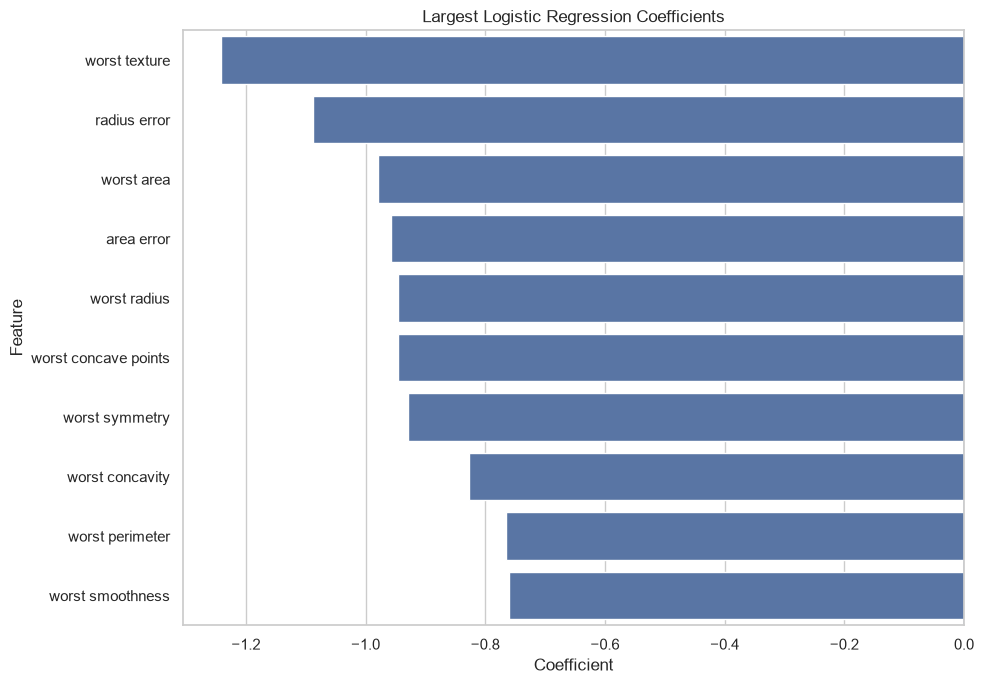

,feature,coefficient,odds_ratio
21,worst texture,-1.242272,0.288727
10,radius error,-1.087929,0.336914
23,worst area,-0.979282,0.375581
13,area error,-0.958096,0.383623
20,worst radius,-0.946000,0.388291
27,worst concave points,-0.945296,0.388565
28,worst symmetry,-0.928729,0.395055
26,worst concavity,-0.827180,0.437281
22,worst perimeter,-0.764807,0.465424
24,worst smoothness,-0.759567,0.467869


In [35]:
# Extract the fitted Logistic Regression estimator.
final_logreg = (
    search
    .best_estimator_
    .named_steps["logreg"]
)

# Create a coefficient table.
coef_df = pd.DataFrame({
    "feature": X_cancer.columns,
    "coefficient": final_logreg.coef_[0]
})

# Calculate absolute coefficient magnitude.
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

# Calculate odds ratios.
coef_df["odds_ratio"] = np.exp(
    coef_df["coefficient"]
)

# Keep the ten largest coefficients.
top_coef = (
    coef_df
    .sort_values("abs_coefficient", ascending=False)
    .head(10)
    .sort_values("coefficient")
)

# Plot the largest positive and negative coefficients.
plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_coef,
    x="coefficient",
    y="feature"
)
plt.axvline(0, linewidth=1)
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Largest Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

# Display the corresponding odds ratios.
display(
    top_coef[
        ["feature", "coefficient", "odds_ratio"]
    ]
)

## 22. Common Failure Modes

### Data problems
- incorrect labels
- duplicate patients
- patient-level leakage
- train/test contamination
- selection bias

### Feature problems
- inconsistent scales
- extreme outliers
- highly correlated variables
- nonlinear relationships
- missing values

### Modeling problems
- inappropriate regularization
- solver non-convergence
- poorly selected hyperparameters
- excessive dimensionality

### Evaluation problems
- accuracy used alone
- threshold tuned on the final test set
- repeated test-set experimentation
- ignored class imbalance
- no external validation

For biomedical machine learning, evaluation design can be as important as the choice of algorithm.

## 23. Logistic Regression in Bioinformatics and Cancer AI

Logistic Regression is a useful baseline for:

- mutation-status prediction
- biomarker classification
- gene-expression classification
- radiomic feature classification
- clinical classification
- imaging-derived feature classification

Its advantages include:
- probabilistic predictions
- a relatively interpretable linear decision function
- efficient optimization
- L1/L2 regularization
- compatibility with high-dimensional feature spaces

Biomedical projects also introduce risks such as:

- repeated measurements from the same patient
- scanner/site confounding
- batch effects
- label leakage
- post-diagnosis variables
- small sample sizes
- high-dimensional predictors
- domain shift

A carefully validated Logistic Regression baseline can therefore be scientifically valuable even when more complex models are planned.

# 24. Final Workflow

A reliable Logistic Regression workflow can be summarized as:

```text
Define the classification problem
        ↓
Inspect labels and class balance
        ↓
Split the data
        ↓
Build a leakage-safe Pipeline
        ↓
Scale features when appropriate
        ↓
Fit Logistic Regression
        ↓
Inspect predicted probabilities
        ↓
Evaluate the confusion matrix
        ↓
Evaluate Precision / Recall / F1 / ROC-AUC
        ↓
Inspect ROC and Precision-Recall curves
        ↓
Select threshold using validation data
        ↓
Tune C using cross-validation
        ↓
Inspect coefficients and errors
        ↓
Evaluate once on untouched test data
        ↓
Consider external validation

# References

### Scikit-learn
- Logistic Regression: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
- Model evaluation: https://scikit-learn.org/stable/modules/model_evaluation.html
- Pipelines: https://scikit-learn.org/stable/modules/compose.html
- Breast Cancer Wisconsin dataset: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
- Iris dataset: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html

### Books
- James, Witten, Hastie & Tibshirani — *An Introduction to Statistical Learning*
- Hastie, Tibshirani & Friedman — *The Elements of Statistical Learning*
- Bishop — *Pattern Recognition and Machine Learning*

This notebook is an educational foundation. Research applications require careful validation of the data-generating process, leakage controls, statistical assumptions, sampling design, and external generalization.